## Category vs. # Answer Choices

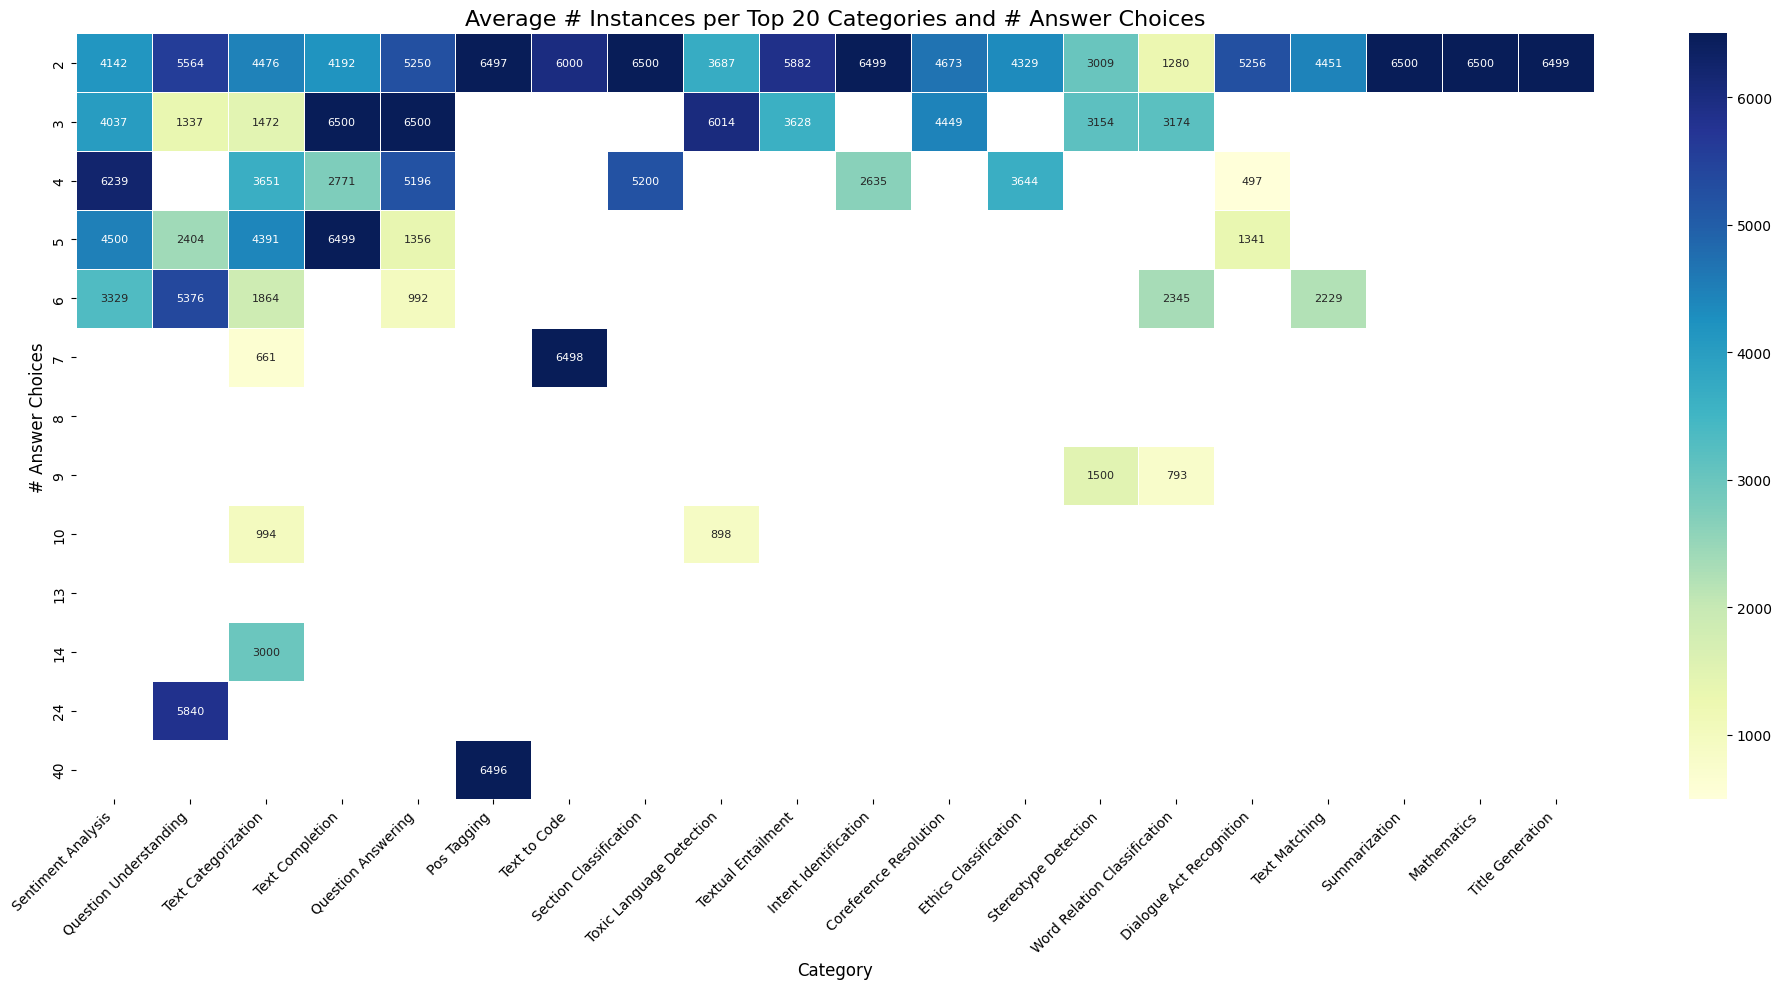

In [5]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

# Load the CSV file 
df = pd.read_csv("test_tasks_info.csv")

# Create a pivot table for heatmap: average # Instances by (# Answer Choices, Category)
heatmap_data = df.pivot_table(
    index='# Answer Choices',
    columns='Category',
    values='# Instances',
    aggfunc='mean'
)

# Select top 20 categories with highest total average instances
top_categories = heatmap_data.sum().sort_values(ascending=False).head(20).index
filtered_heatmap_data = heatmap_data[top_categories]

# Plot the heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(
    filtered_heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    annot_kws={"size": 8}  # Smaller font size for annotations
)

plt.title('Average # Instances per Top 20 Categories and # Answer Choices', fontsize=16)
plt.ylabel('# Answer Choices', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Heatmap annotated with 95% CIs (mean + [low, high])

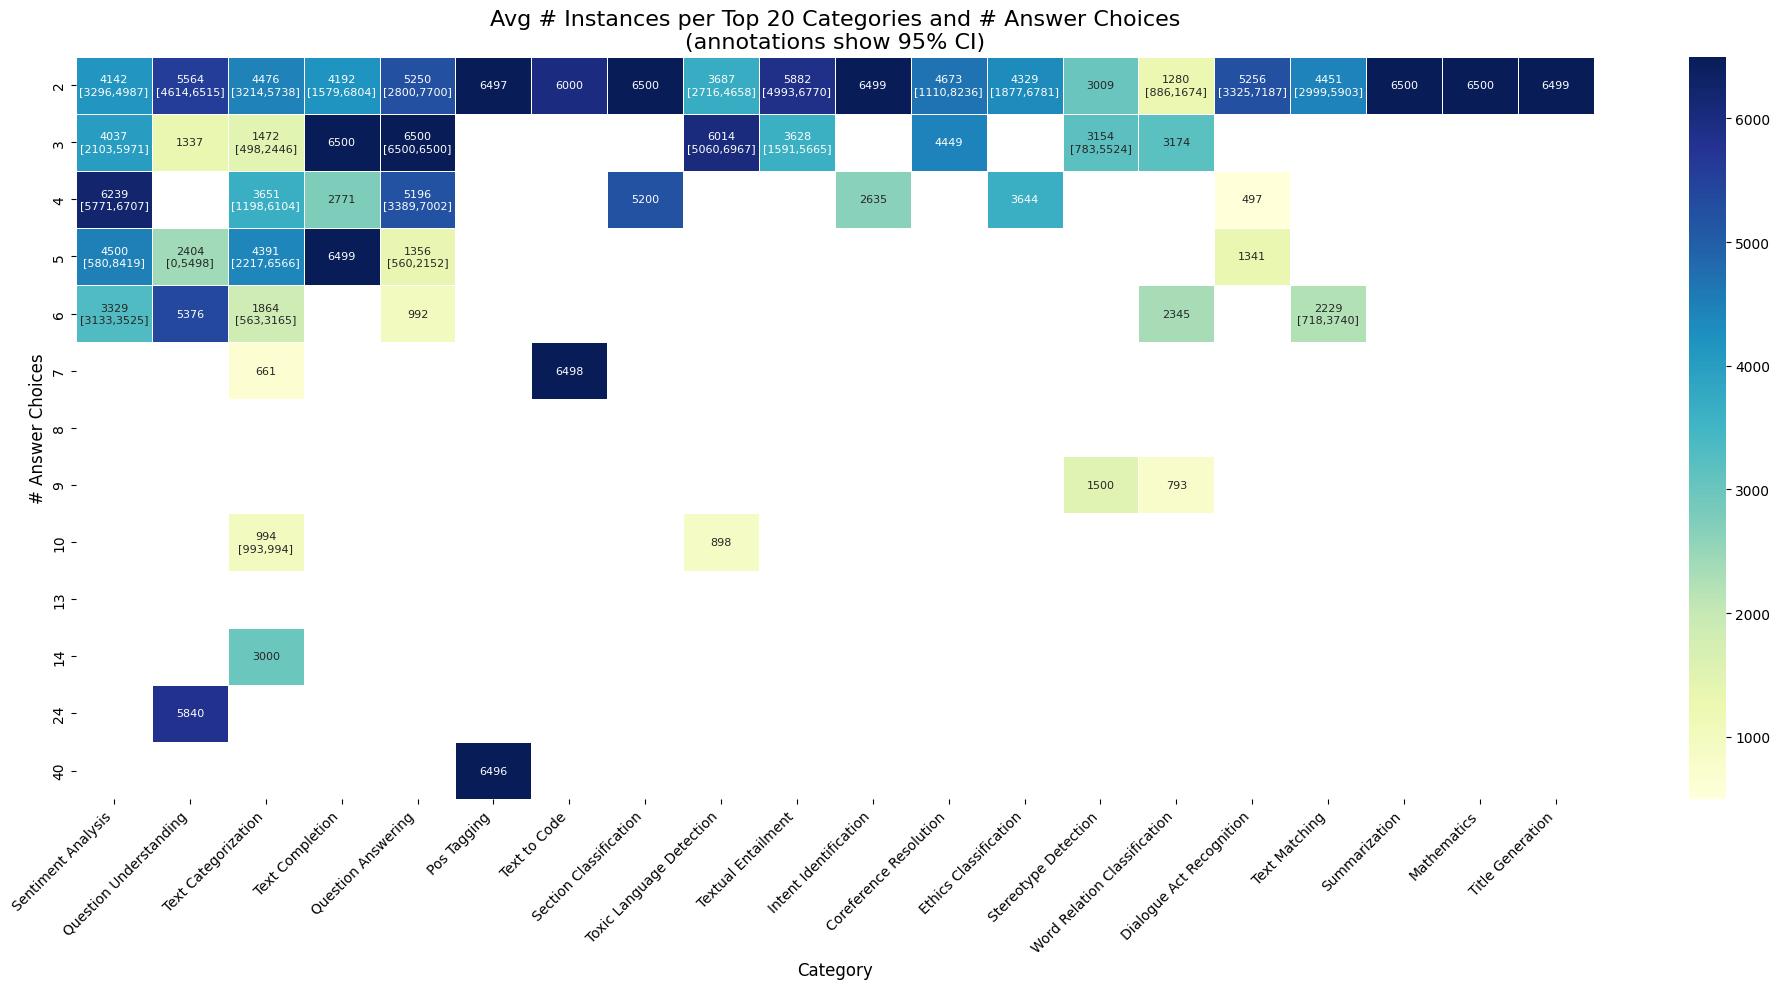

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv("test_tasks_info.csv")

# ---- 1) Compute mean, std, count, SE, and 95% CI per (# Answer Choices, Category)
g = (df.groupby(['# Answer Choices', 'Category'])['# Instances']
       .agg(['mean', 'std', 'count'])
       .reset_index())
g['se'] = g['std'] / np.sqrt(g['count']).replace(0, np.nan)
z = 1.96  # 95% CI
g['ci_low']  = g['mean'] - z * g['se']
g['ci_high'] = g['mean'] + z * g['se']

# ---- 2) Pivot to matrices for heatmap values (mean) and annotations (text with CI)
heat_mean = g.pivot(index='# Answer Choices', columns='Category', values='mean')

# Build text labels like: "123\n[110, 135]" (you can switch to ±: "123 ± 12")
def _label(r):
    # guard against NaN SE (single item groups)
    if pd.isna(r['se']):
        return f"{r['mean']:.0f}"
    lo = max(r['ci_low'], 0) if pd.notna(r['ci_low']) else r['mean']
    hi = r['ci_high'] if pd.notna(r['ci_high']) else r['mean']
    return f"{r['mean']:.0f}\n[{lo:.0f},{hi:.0f}]"

g['label'] = g.apply(_label, axis=1)
heat_annot = g.pivot(index='# Answer Choices', columns='Category', values='label')

# ---- 3) Select top 20 categories by total mean across answer-choice rows
top_categories = (heat_mean.sum()
                  .sort_values(ascending=False)
                  .head(20)
                  .index)

heat_mean_top  = heat_mean[top_categories]
heat_annot_top = heat_annot[top_categories]

# ---- 4) Plot heatmap of MEAN values, with CI annotations
plt.figure(figsize=(20, 10))
sns.heatmap(
    heat_mean_top,
    annot=heat_annot_top,   # the string grid (mean + CI)
    fmt="",                 # strings already formatted
    cmap="YlGnBu",
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title('Avg # Instances per Top 20 Categories and # Answer Choices\n(annotations show 95% CI)', fontsize=16)
plt.ylabel('# Answer Choices', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Companion bar chart with error bars (classic)

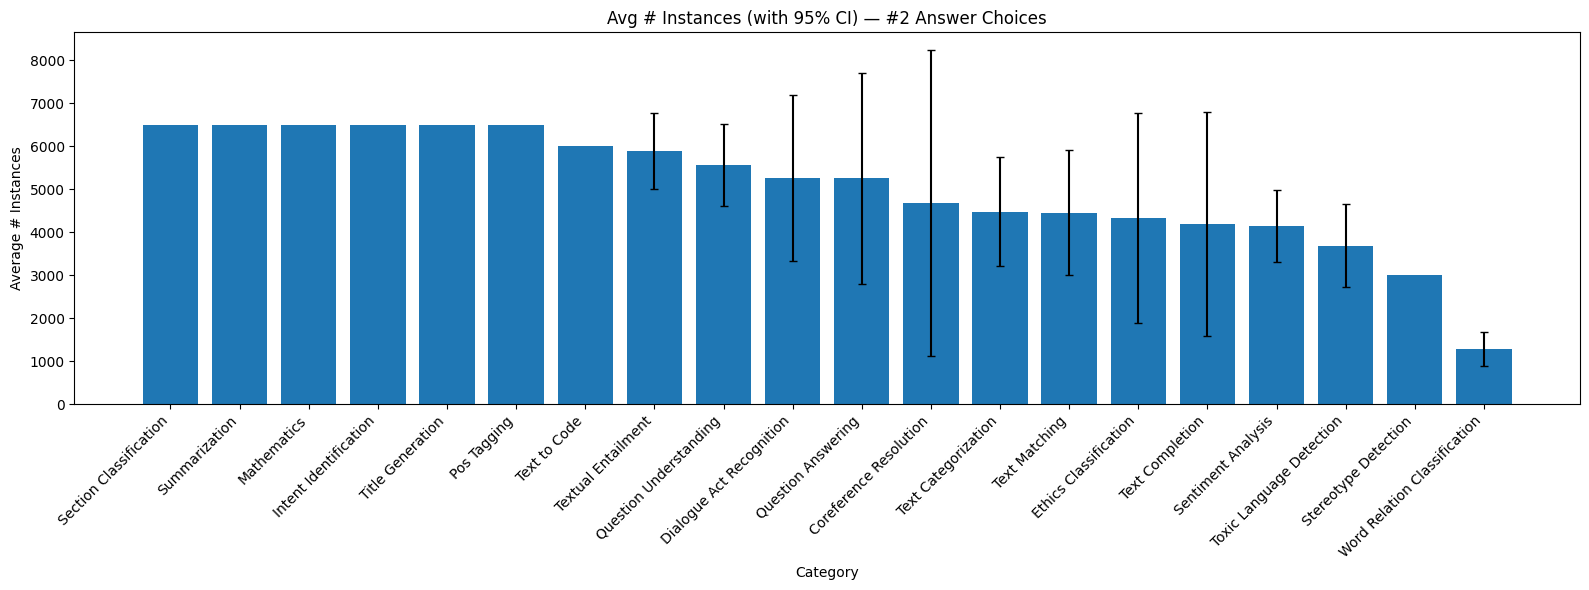

In [6]:
# Slice one row of the heatmap space, e.g., 2-answer tasks
row_k = 2
g2 = g[g['# Answer Choices'] == row_k].copy()

# Keep top 20 categories used above for consistency
g2 = g2[g2['Category'].isin(top_categories)]

# Sort by mean
g2 = g2.sort_values('mean', ascending=False)

# Bar chart with error bars (95% CI)
plt.figure(figsize=(16, 6))
plt.bar(g2['Category'], g2['mean'], yerr=1.96 * g2['se'], capsize=3)
plt.title(f'Avg # Instances (with 95% CI) — #{row_k} Answer Choices')
plt.ylabel('Average # Instances')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Task vs. Label Frequencies (Label Imbalance)

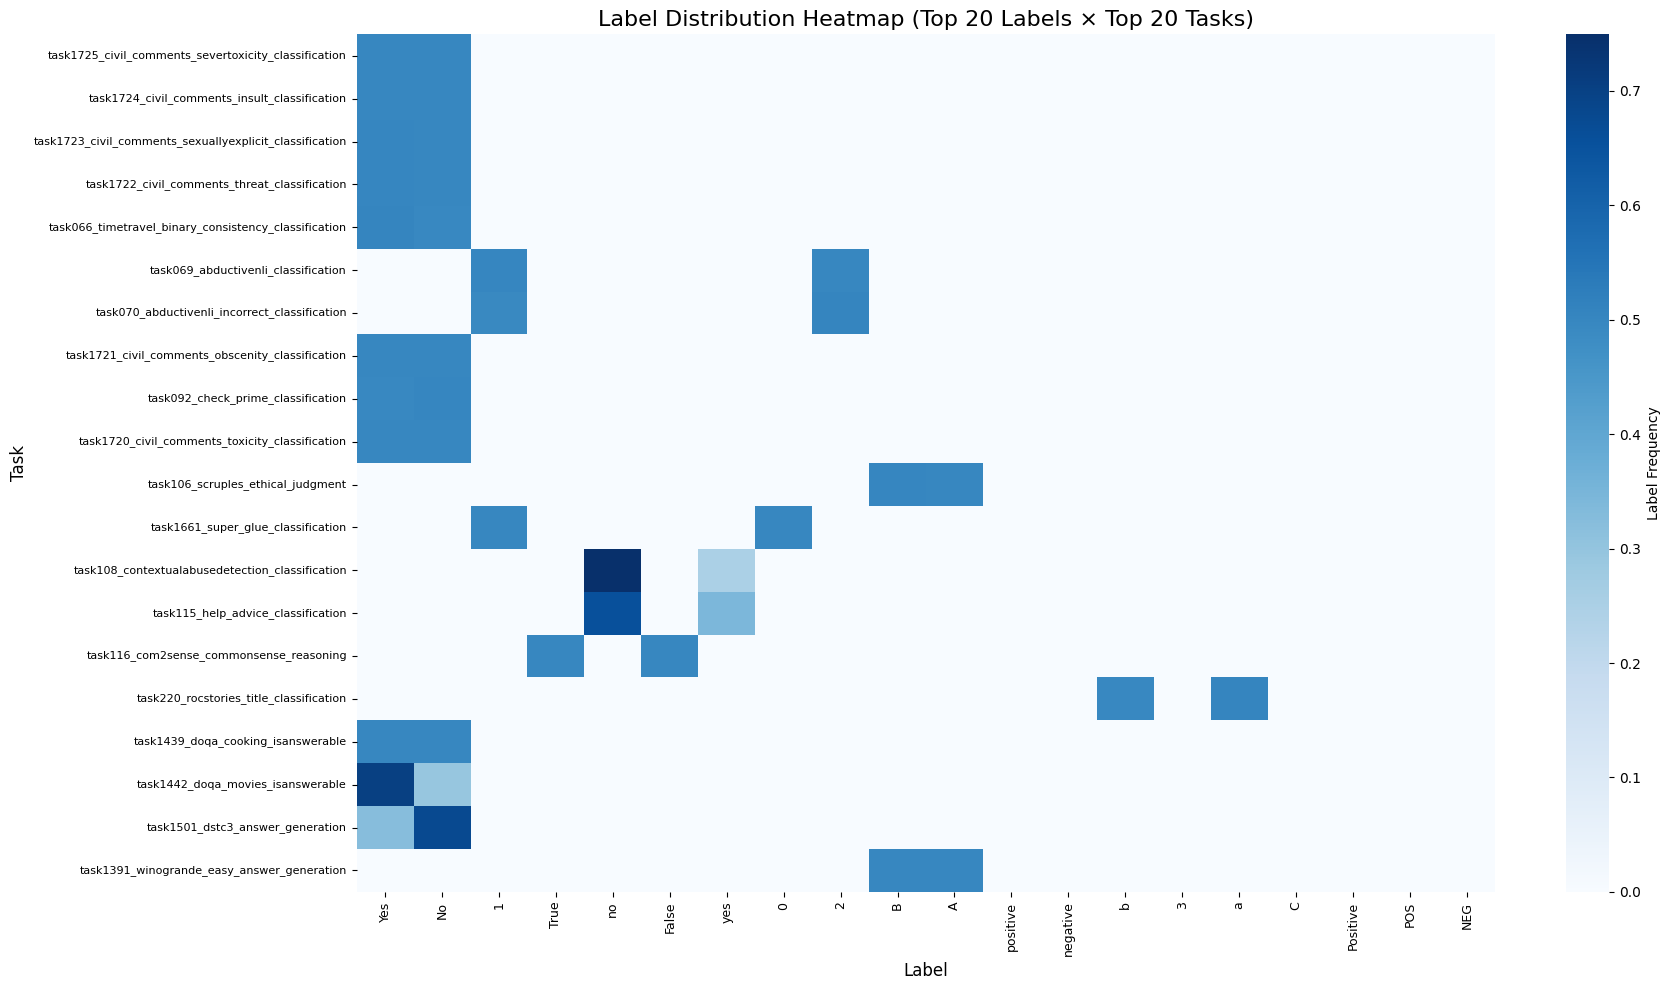

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Load the CSV file
df = pd.read_csv("test_tasks_info.csv")

# Create label distribution DataFrame
label_dist_df = pd.DataFrame()

for i, row in df.iterrows():
    task_name = row['Name']
    dist_dict = ast.literal_eval(row['Labels Distribution'])
    dist_series = pd.Series(dist_dict, name=task_name)
    label_dist_df = pd.concat([label_dist_df, dist_series], axis=1)

label_dist_df = label_dist_df.fillna(0)

# Keep only top 20 labels across all tasks
top_labels = label_dist_df.sum(axis=1).sort_values(ascending=False).head(20).index
filtered_label_dist_df = label_dist_df.loc[top_labels]

# Keep only top 20 tasks with highest total label frequency
top_tasks = filtered_label_dist_df.T.sum(axis=1).sort_values(ascending=False).head(20).index
filtered_label_dist_df = filtered_label_dist_df.loc[:, top_tasks].T

# Plot the heatmap
plt.figure(figsize=(18, 10))
sns.heatmap(
    filtered_label_dist_df,
    cmap="Blues",  # changed from "YlOrRd"
    cbar_kws={'label': 'Label Frequency'}
)

plt.title('Label Distribution Heatmap (Top 20 Labels × Top 20 Tasks)', fontsize=16)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Task', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


### Heatmap with CI annotations (proportions per cell)

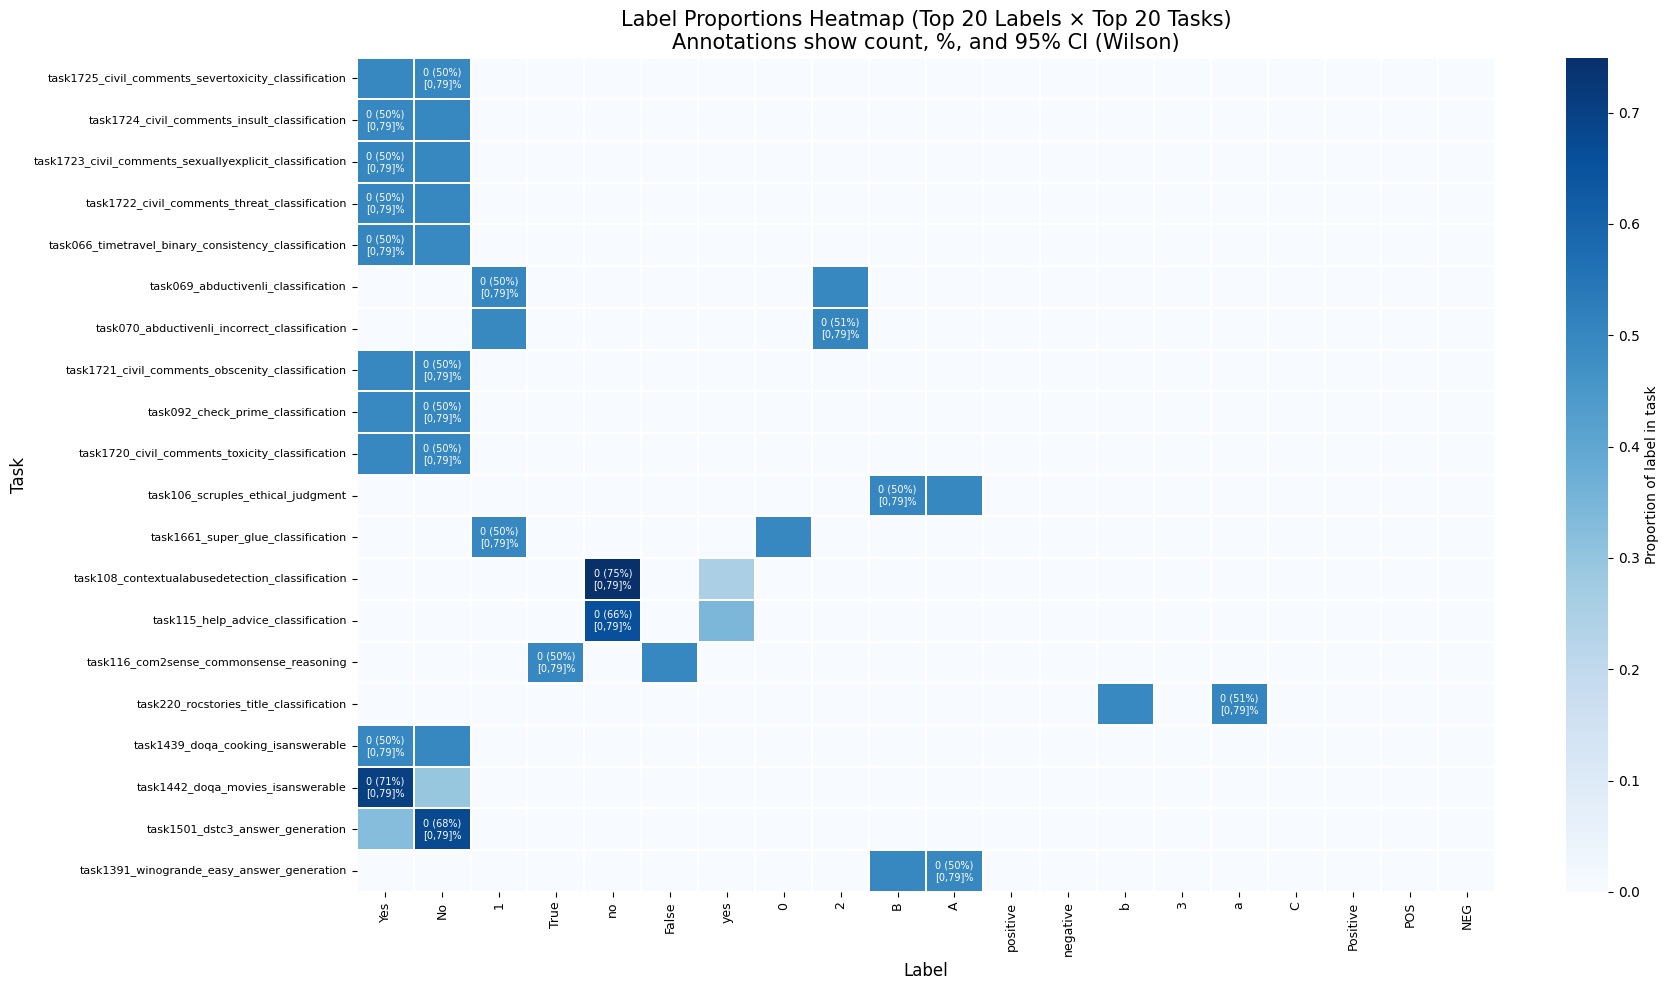

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from math import sqrt

# --- your existing load + build ---
df = pd.read_csv("test_tasks_info.csv")

label_dist_df = pd.DataFrame()
for _, row in df.iterrows():
    task_name = row['Name']
    dist_dict = ast.literal_eval(row['Labels Distribution'])  # {label: count}
    dist_series = pd.Series(dist_dict, name=task_name)
    label_dist_df = pd.concat([label_dist_df, dist_series], axis=1)

label_dist_df = label_dist_df.fillna(0)

# Keep only top 20 labels across all tasks
top_labels = label_dist_df.sum(axis=1).sort_values(ascending=False).head(20).index
filtered_label_dist_df = label_dist_df.loc[top_labels]

# Keep only top 20 tasks with highest total label frequency
top_tasks = filtered_label_dist_df.T.sum(axis=1).sort_values(ascending=False).head(20).index
# Final matrix: tasks x labels (rows=tasks, cols=labels)
filtered_label_dist_df = filtered_label_dist_df.loc[:, top_tasks].T

# --- compute proportions and 95% Wilson CIs for each cell ---
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2/(2*n)) / denom
    half = z * sqrt((p*(1-p)/n) + (z**2/(4*n**2))) / denom
    return (max(0.0, center - half), min(1.0, center + half))

# totals per task (row sum)
n_per_task = filtered_label_dist_df.sum(axis=1)

# proportions
prop_df = filtered_label_dist_df.div(n_per_task.replace(0, np.nan), axis=0)

# annotation strings (to avoid clutter, only annotate the max label per task)
ANNOTATE_MAX_ONLY = True
annot_df = pd.DataFrame("", index=filtered_label_dist_df.index, columns=filtered_label_dist_df.columns)

for task in filtered_label_dist_df.index:
    n = n_per_task.loc[task]
    if n == 0:
        continue
    # choose labels to annotate
    labels_to_annotate = [filtered_label_dist_df.loc[task].idxmax()] if ANNOTATE_MAX_ONLY else filtered_label_dist_df.columns
    for lab in labels_to_annotate:
        k = filtered_label_dist_df.loc[task, lab]
        p = k / n
        lo, hi = wilson_ci(int(k), int(n))
        annot_df.loc[task, lab] = f"{int(k)} ({p*100:.0f}%)\n[{lo*100:.0f},{hi*100:.0f}]%"

# --- plot heatmap of PROPORTIONS with CI annotations on key cells ---
plt.figure(figsize=(18, 10))
sns.heatmap(
    prop_df,                # color = proportion
    cmap="Blues",
    cbar_kws={'label': 'Proportion of label in task'},
    annot=annot_df,         # strings we built (only for selected cells)
    fmt="",
    linewidths=0.3,
    annot_kws={"size": 7}
)
plt.title('Label Proportions Heatmap (Top 20 Labels × Top 20 Tasks)\nAnnotations show count, %, and 95% CI (Wilson)', fontsize=15)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Task', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Top labels within one task (with 95% CIs)

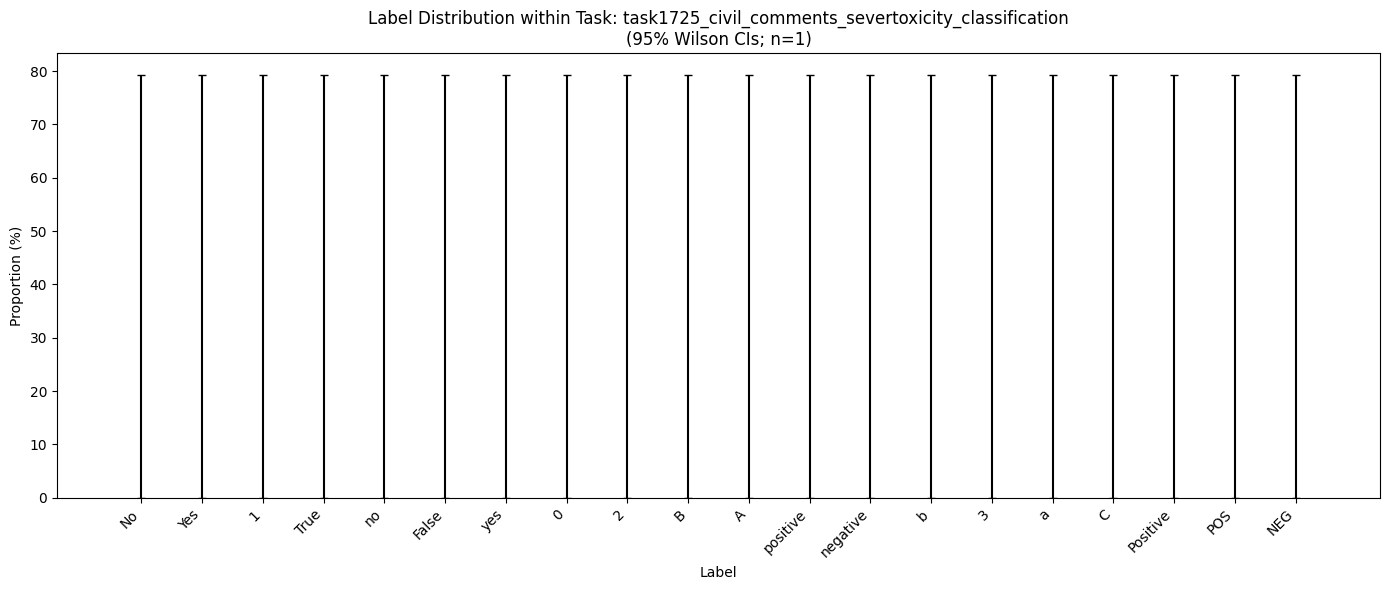

In [11]:
# pick a task to highlight (e.g., the most frequent)
focus_task = prop_df.index[0]  # or choose manually

counts = filtered_label_dist_df.loc[focus_task].sort_values(ascending=False)
n = int(n_per_task.loc[focus_task])
labels = counts.index.tolist()
ks = counts.values.astype(int)

# compute Wilson CIs for proportions
def batch_wilson(ks, n):
    los, his = [], []
    for k in ks:
        lo, hi = wilson_ci(int(k), n)
        los.append(lo); his.append(hi)
    return np.array(los), np.array(his)

los, his = batch_wilson(ks, n)
ps = ks / n
y = ps * 100
yerr = np.vstack([(ps - los)*100, (his - ps)*100])  # asymmetric

plt.figure(figsize=(14, 6))
plt.bar(labels, y, yerr=yerr, capsize=3)
plt.ylabel('Proportion (%)')
plt.xlabel('Label')
plt.title(f'Label Distribution within Task: {focus_task}\n(95% Wilson CIs; n={n})')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### One label across tasks (with 95% CIs)

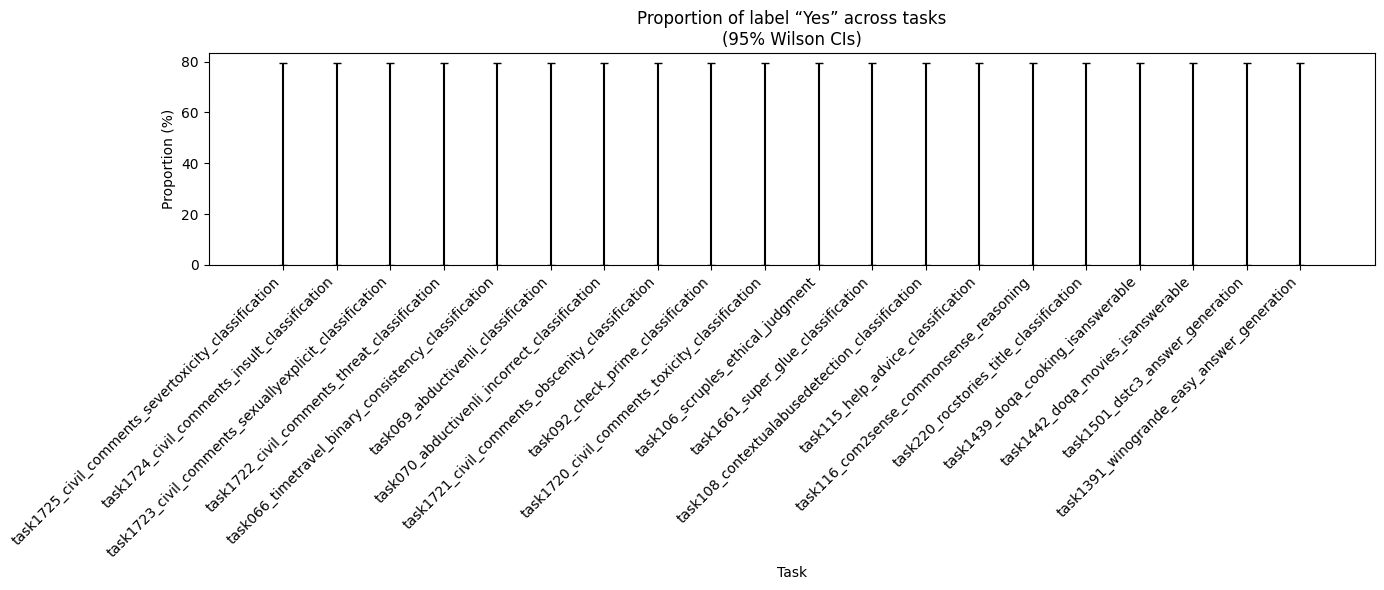

In [12]:
# pick a label to highlight (e.g., most frequent overall)
focus_label = prop_df.columns[0]  # or choose manually

ks = filtered_label_dist_df[focus_label].astype(int).values
ns = n_per_task.astype(int).values
tasks = filtered_label_dist_df.index.tolist()

# compute per-task CIs
ps = ks / ns.clip(min=1)
los = np.zeros_like(ps, dtype=float)
his = np.zeros_like(ps, dtype=float)
for i, (k, n) in enumerate(zip(ks, ns)):
    lo, hi = wilson_ci(int(k), int(n)) if n > 0 else (np.nan, np.nan)
    los[i], his[i] = lo, hi

y = ps * 100
yerr = np.vstack([(ps - los)*100, (his - ps)*100])

# sort tasks by proportion for readability
order = np.argsort(-y)
tasks_s = [tasks[i] for i in order]
y_s = y[order]
yerr_s = yerr[:, order]

plt.figure(figsize=(14, 6))
plt.bar(tasks_s, y_s, yerr=yerr_s, capsize=3)
plt.ylabel('Proportion (%)')
plt.xlabel('Task')
plt.title(f'Proportion of label “{focus_label}” across tasks\n(95% Wilson CIs)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 

## Standard Deviation of Instance Counts

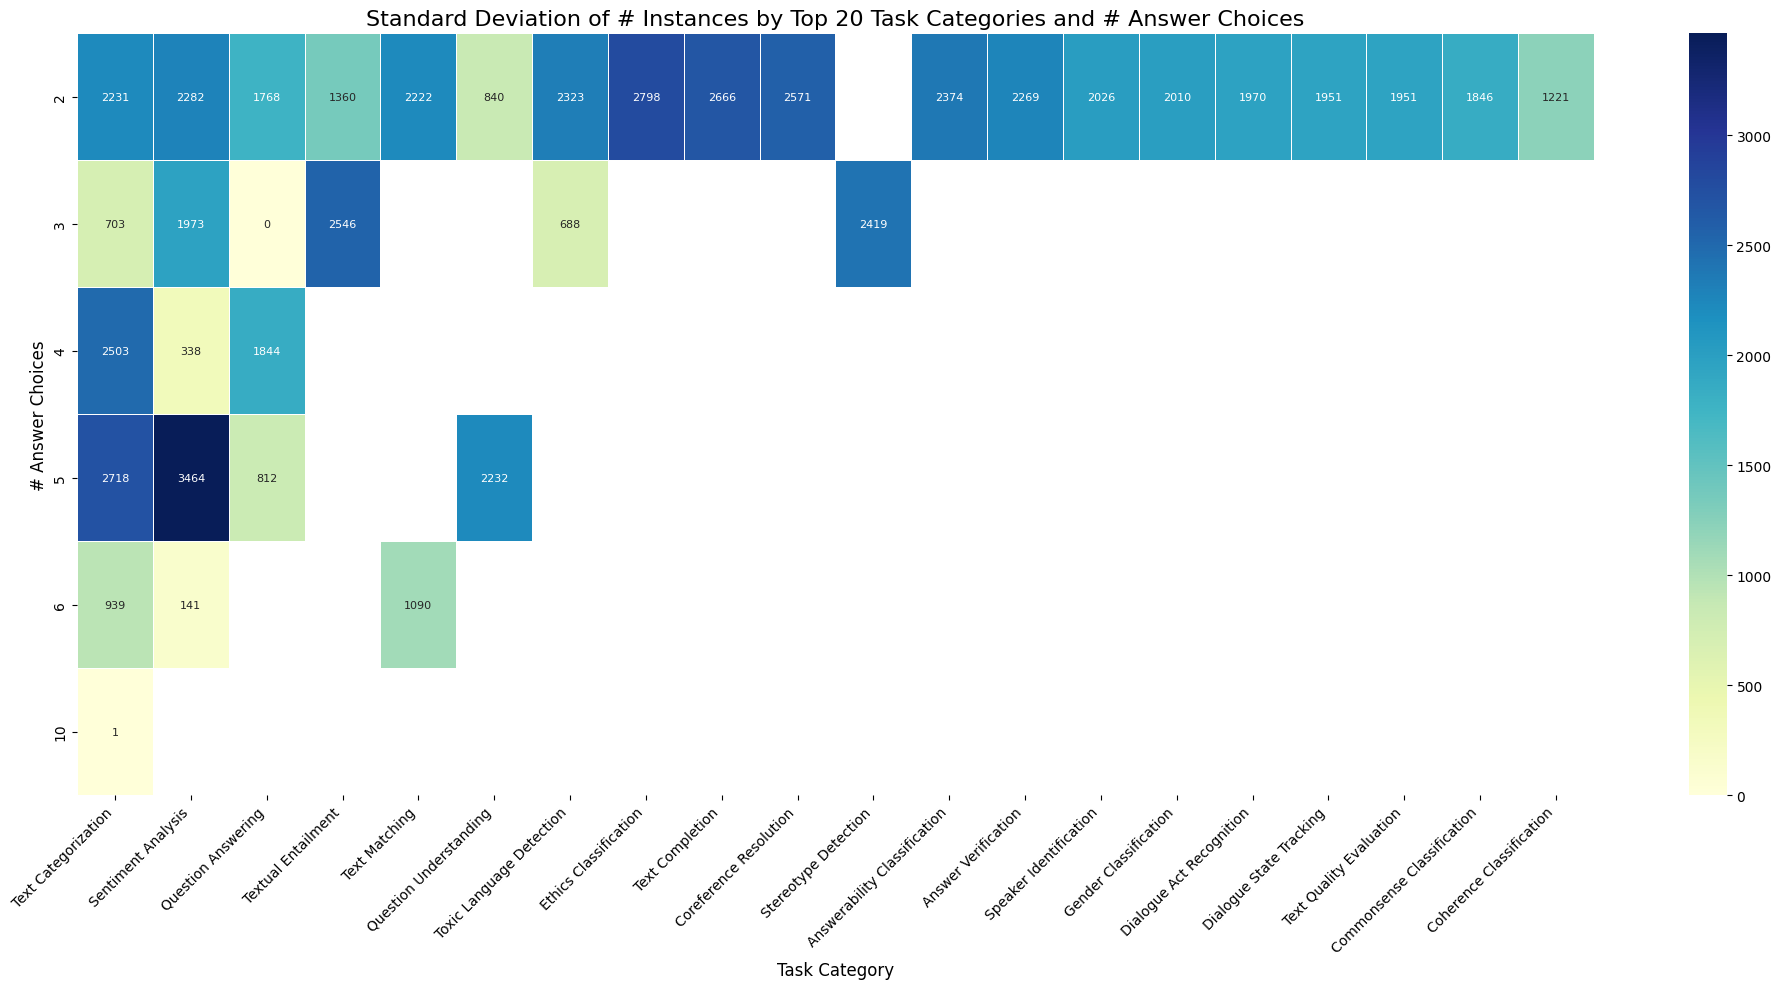

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv("test_tasks_info.csv")

# Create pivot table using standard deviation
pivot_df = df.pivot_table(
    index='# Answer Choices',
    columns='Category',
    values='# Instances',
    aggfunc='std'  # Change from 'mean' to 'std' to show variability
)

# Filter to top 20 categories with highest total standard deviation
top_categories = pivot_df.sum().sort_values(ascending=False).head(20).index
filtered_pivot_df = pivot_df[top_categories]

# Plot the heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(
    filtered_pivot_df,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",  # Blue-green palette
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title('Standard Deviation of # Instances by Top 20 Task Categories and # Answer Choices', fontsize=16)
plt.ylabel('# Answer Choices', fontsize=12)
plt.xlabel('Task Category', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()



### Heatmap of STD with 95% CI annotations (bootstrap)

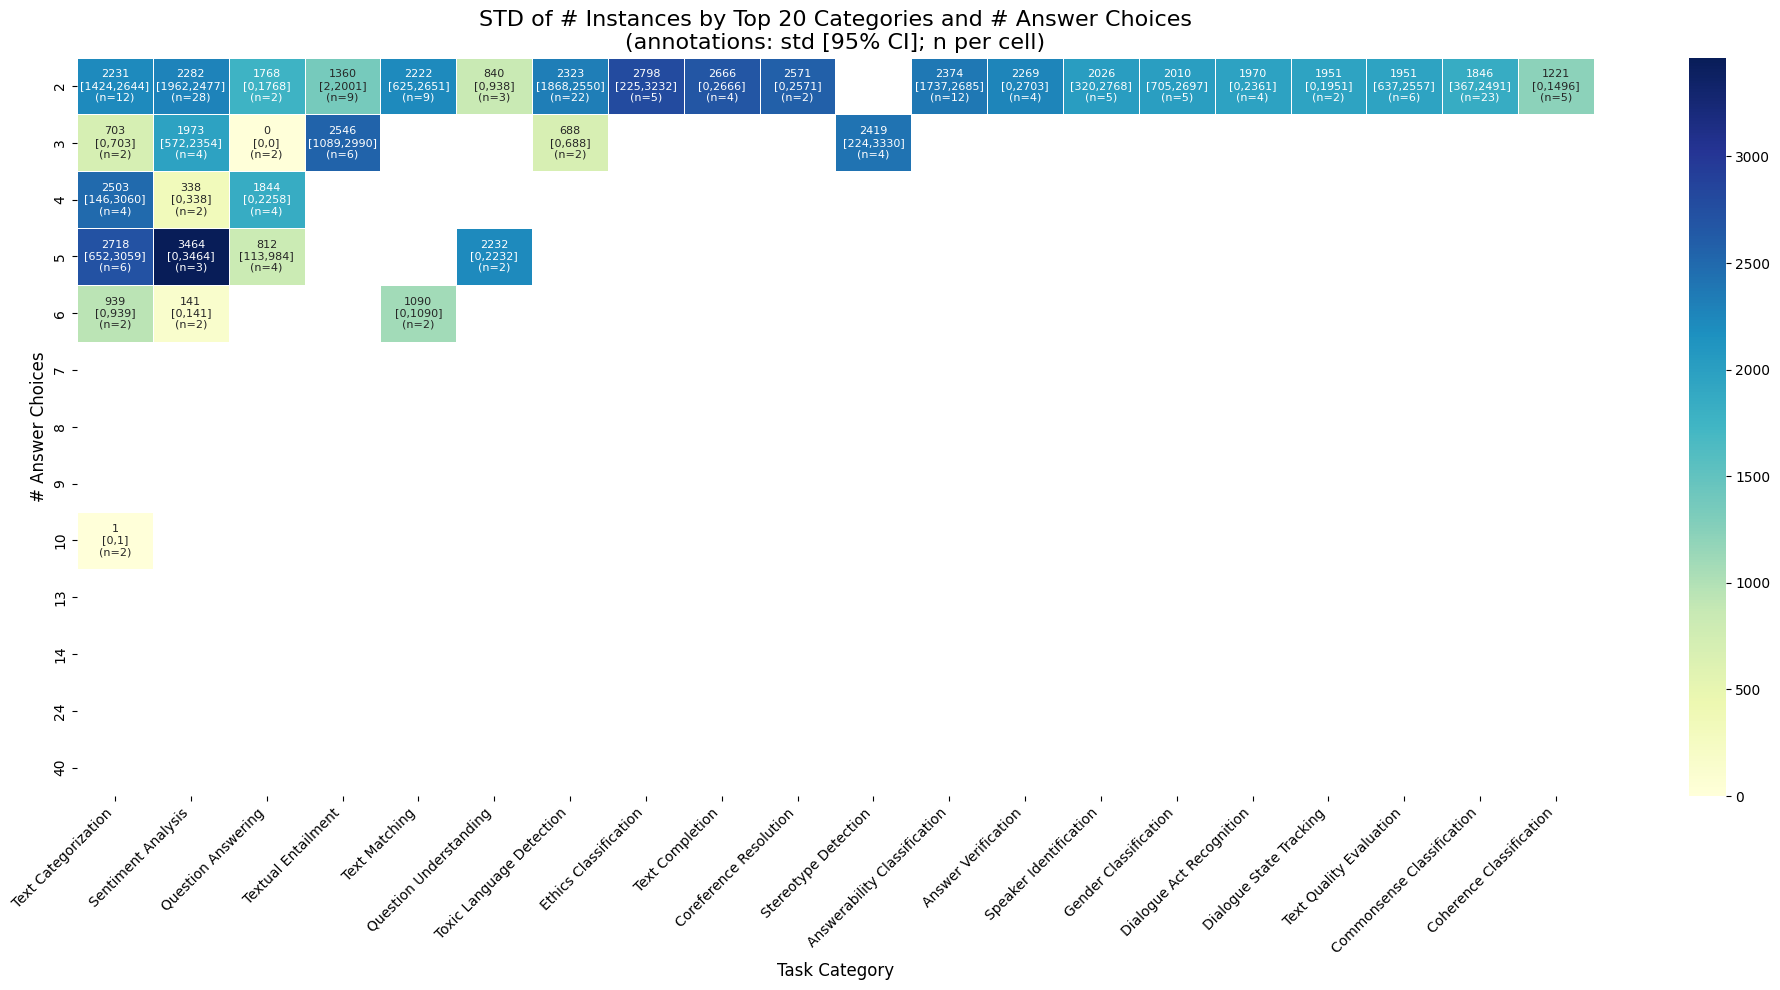

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- load ---
df = pd.read_csv("test_tasks_info.csv")

# --- gather values per group: (# Answer Choices, Category) ---
# we keep the raw values so we can bootstrap the std per cell
grp = (df.groupby(['# Answer Choices', 'Category'])['# Instances']
         .agg(list)
         .reset_index()
         .rename(columns={'# Instances': 'values'}))

def bootstrap_std_ci(vals, B=1000, alpha=0.05, rng_seed=0):
    vals = np.asarray(vals, dtype=float)
    n = len(vals)
    if n < 2:  # std undefined with <2 points
        return np.nan, n, np.nan, np.nan
    s = np.std(vals, ddof=1)
    # bootstrap resampling over the set of values in this cell
    rng = np.random.default_rng(rng_seed)
    boots = []
    for _ in range(B):
        samp = rng.choice(vals, size=n, replace=True)
        if n >= 2:
            boots.append(np.std(samp, ddof=1))
    if len(boots) == 0:
        return s, n, np.nan, np.nan
    lo = np.percentile(boots, 100*alpha/2)
    hi = np.percentile(boots, 100*(1 - alpha/2))
    return s, n, lo, hi

rows = []
for _, r in grp.iterrows():
    s, n, lo, hi = bootstrap_std_ci(r['values'], B=1000, alpha=0.05, rng_seed=42)
    rows.append({
        '# Answer Choices': r['# Answer Choices'],
        'Category': r['Category'],
        'std': s,
        'n': n,
        'ci_low': lo,
        'ci_high': hi
    })

stats_df = pd.DataFrame(rows)

# --- pivot for heatmap values and annotations ---
heat_std = stats_df.pivot(index='# Answer Choices', columns='Category', values='std')

def fmt_cell(row):
    if np.isnan(row['std']):
        return ""
    if np.isnan(row['ci_low']) or np.isnan(row['ci_high']):
        return f"{row['std']:.0f}\n(n={int(row['n'])})"
    return f"{row['std']:.0f}\n[{row['ci_low']:.0f},{row['ci_high']:.0f}]\n(n={int(row['n'])})"

stats_df['label'] = stats_df.apply(fmt_cell, axis=1)
heat_annot = stats_df.pivot(index='# Answer Choices', columns='Category', values='label')

# --- select top 20 categories by total std (sum across answer-choice rows) ---
top_categories = (heat_std.sum()
                  .sort_values(ascending=False)
                  .head(20)
                  .index)

heat_std_top  = heat_std[top_categories]
heat_annot_top = heat_annot[top_categories]

# --- plot heatmap (color = std; annotation = std [lo, hi], n) ---
plt.figure(figsize=(20, 10))
sns.heatmap(
    heat_std_top,
    annot=heat_annot_top,   # show CI + n as strings
    fmt="",
    cmap="YlGnBu",
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title('STD of # Instances by Top 20 Categories and # Answer Choices\n(annotations: std [95% CI]; n per cell)', fontsize=16)
plt.ylabel('# Answer Choices', fontsize=12)
plt.xlabel('Task Category', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


### Companion bar chart (recommended for the paper): STD with 95% CI

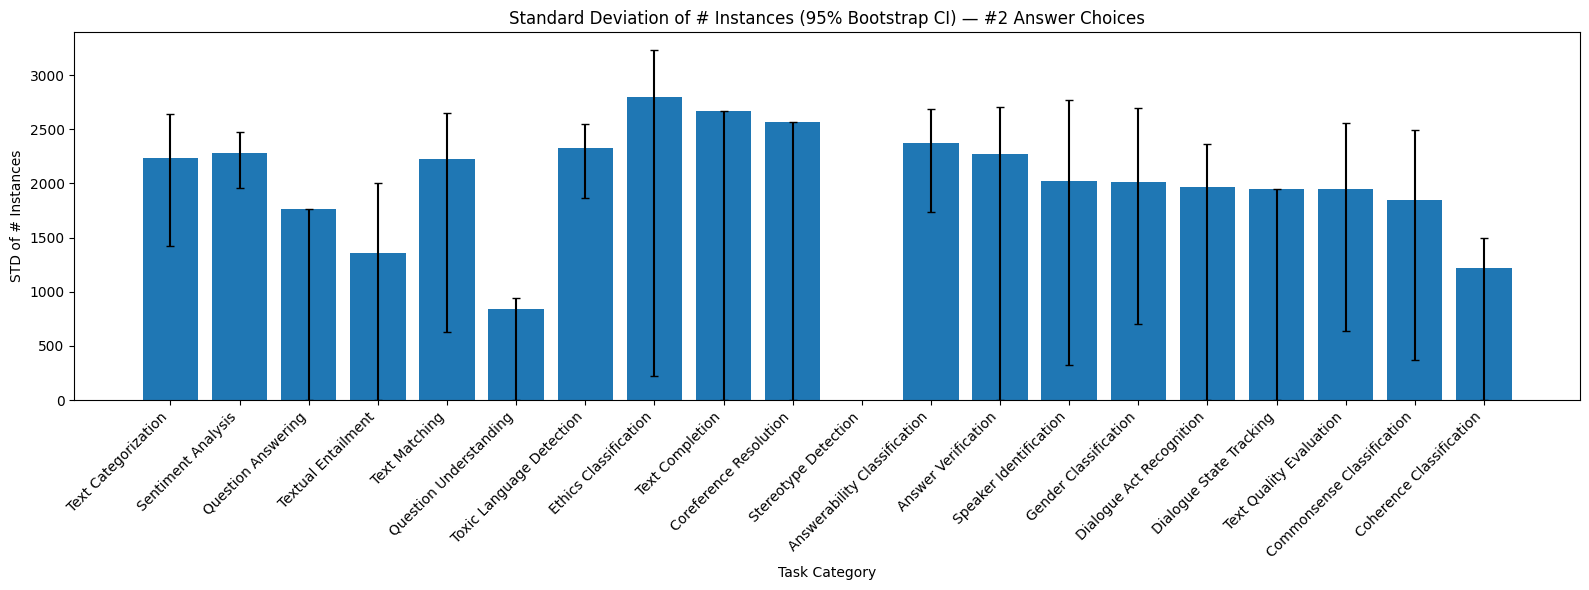

In [7]:
# choose a row to highlight
row_k = heat_std_top.index[0]  # or set explicitly, e.g., row_k = 2

sub = stats_df[stats_df['# Answer Choices'] == row_k].copy()
sub = sub[sub['Category'].isin(top_categories)]

# keep same top-20 ordering by total std
order = list(top_categories)
sub['Category'] = pd.Categorical(sub['Category'], categories=order, ordered=True)
sub = sub.sort_values('Category')

y = sub['std'].values
# asymmetric yerr from bootstrap CIs
ci_low = sub['ci_low'].values
ci_high = sub['ci_high'].values
# handle NaNs: replace with zeros to avoid matplotlib errors (bars will have no whiskers)
yerr_lo = np.where(np.isnan(ci_low), 0.0, y - ci_low)
yerr_hi = np.where(np.isnan(ci_high), 0.0, ci_high - y)
yerr = np.vstack([yerr_lo, yerr_hi])

plt.figure(figsize=(16, 6))
plt.bar(sub['Category'].astype(str), y, yerr=yerr, capsize=3)
plt.title(f'Standard Deviation of # Instances (95% Bootstrap CI) — #{row_k} Answer Choices')
plt.ylabel('STD of # Instances')
plt.xlabel('Task Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Visualization

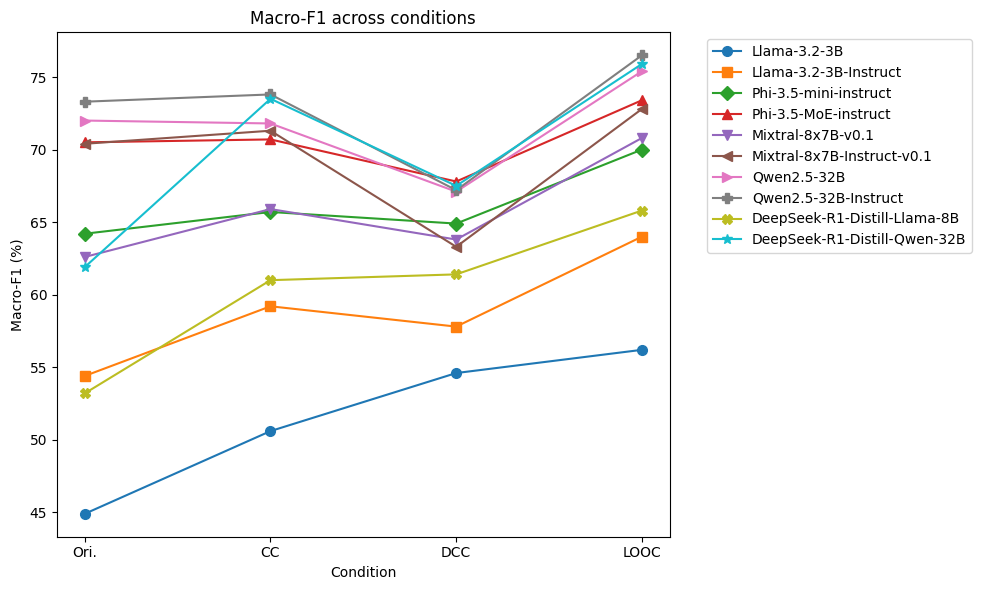

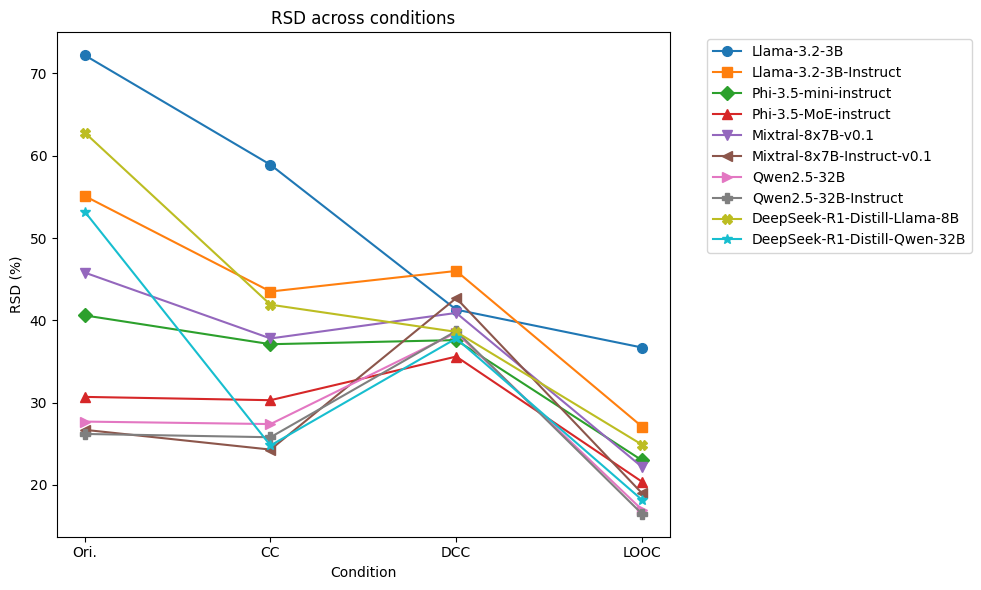

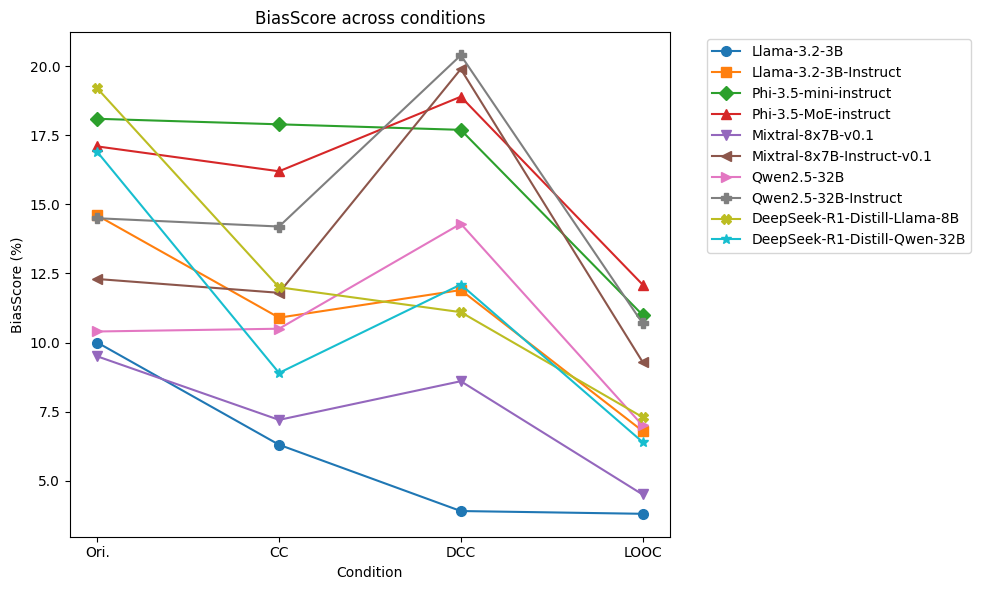

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle

# -----------------------------
# 1) Data (percent values)
# -----------------------------
models = [
    "Llama-3.2-3B",
    "Llama-3.2-3B-Instruct",
    "Phi-3.5-mini-instruct",
    "Phi-3.5-MoE-instruct",
    "Mixtral-8x7B-v0.1",
    "Mixtral-8x7B-Instruct-v0.1",
    "Qwen2.5-32B",
    "Qwen2.5-32B-Instruct",
    "DeepSeek-R1-Distill-Llama-8B",
    "DeepSeek-R1-Distill-Qwen-32B",
]
conditions = ["Ori.", "CC", "DCC", "LOOC"]

macro_f1 = [
    [44.9, 50.6, 54.6, 56.2],
    [54.4, 59.2, 57.8, 64.0],
    [64.2, 65.7, 64.9, 70.0],
    [70.5, 70.7, 67.8, 73.4],
    [62.6, 65.9, 63.8, 70.8],
    [70.4, 71.3, 63.3, 72.8],
    [72.0, 71.8, 67.1, 75.4],
    [73.3, 73.8, 67.2, 76.5],
    [53.2, 61.0, 61.4, 65.8],
    [61.9, 73.5, 67.5, 75.9],
]

rsd = [
    [72.2, 58.9, 41.3, 36.7],
    [55.1, 43.5, 46.0, 27.1],
    [40.6, 37.1, 37.6, 23.0],
    [30.7, 30.3, 35.6, 20.4],
    [45.8, 37.8, 40.9, 22.2],
    [26.7, 24.3, 42.7, 19.0],
    [27.7, 27.4, 38.5, 17.0],
    [26.2, 25.8, 38.7, 16.5],
    [62.8, 41.9, 38.6, 24.9],
    [53.2, 24.8, 37.8, 18.2],
]

bias = [
    [10.0, 6.3, 3.9, 3.8],
    [14.6, 10.9, 11.9, 6.8],
    [18.1, 17.9, 17.7, 11.0],
    [17.1, 16.2, 18.9, 12.1],
    [9.5, 7.2, 8.6, 4.5],
    [12.3, 11.8, 19.9, 9.3],
    [10.4, 10.5, 14.3, 7.0],
    [14.5, 14.2, 20.4, 10.7],
    [19.2, 12.0, 11.1, 7.3],
    [16.9, 8.9, 12.1, 6.4],
]

# -----------------------------
# 2) Build a tidy DataFrame
# -----------------------------
records = []
for i, model in enumerate(models):
    for j, cond in enumerate(conditions):
        records.append({
            "Model": model,
            "Condition": cond,
            "Macro-F1": macro_f1[i][j],
            "RSD": rsd[i][j],
            "BiasScore": bias[i][j],
        })
df = pd.DataFrame.from_records(records)

# Ensure conditions are ordered correctly on the x-axis
df["Condition"] = pd.Categorical(df["Condition"], categories=conditions, ordered=True)

# -----------------------------
# 3) Plot line charts with different markers
# -----------------------------
MARKERS = ["o", "s", "D", "^", "v", "<", ">", "P", "X", "*", "h", "H", "8", "p"]

for metric in ["Macro-F1", "RSD", "BiasScore"]:
    plt.figure(figsize=(10, 6))
    marker_cycle = cycle(MARKERS)

    for model in models:
        subset = df[df["Model"] == model]
        m = next(marker_cycle)  # assign a marker to this model
        plt.plot(
            subset["Condition"],
            subset[metric],
            marker=m,
            linestyle="-",
            linewidth=1.5,
            markersize=7,
            label=model,
        )

    plt.title(f"{metric} across conditions")
    plt.ylabel(f"{metric} (%)")
    plt.xlabel("Condition")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Task Complexity

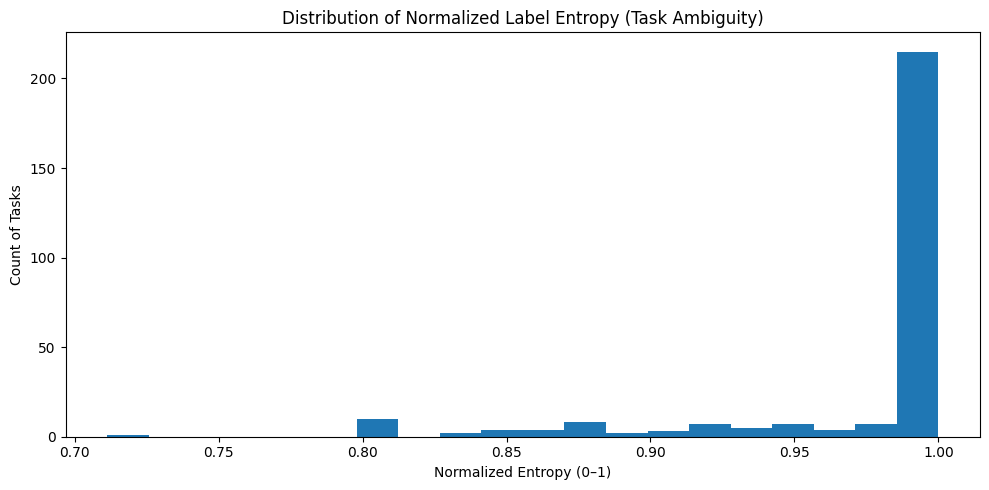

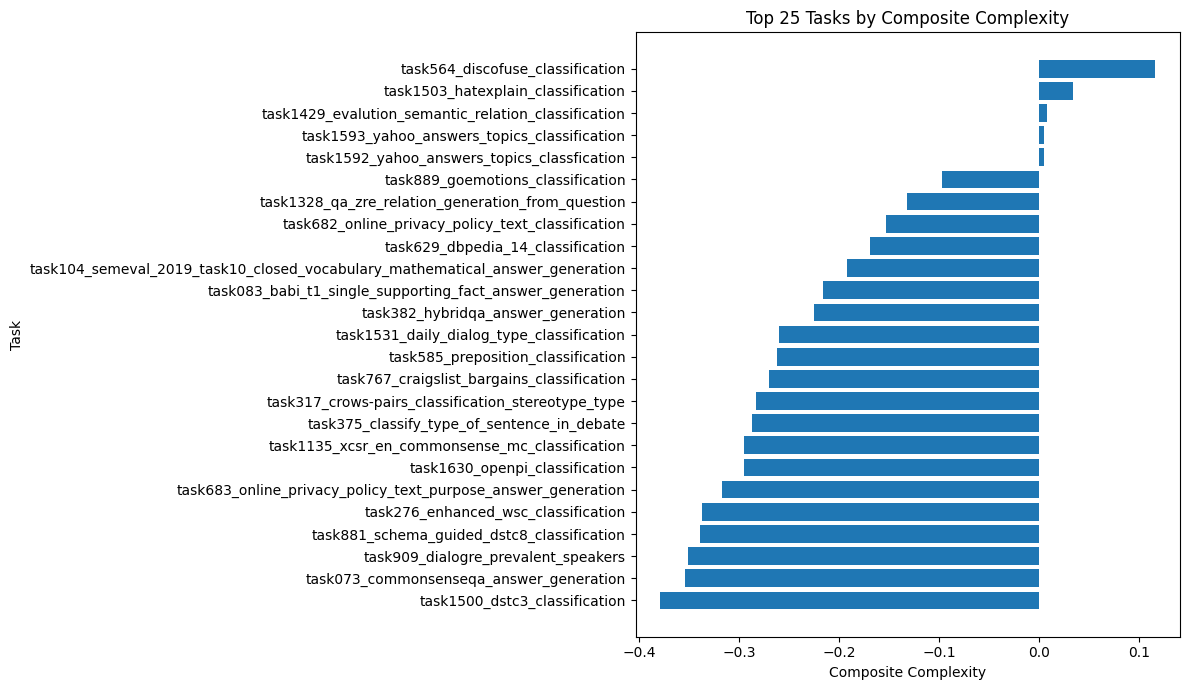

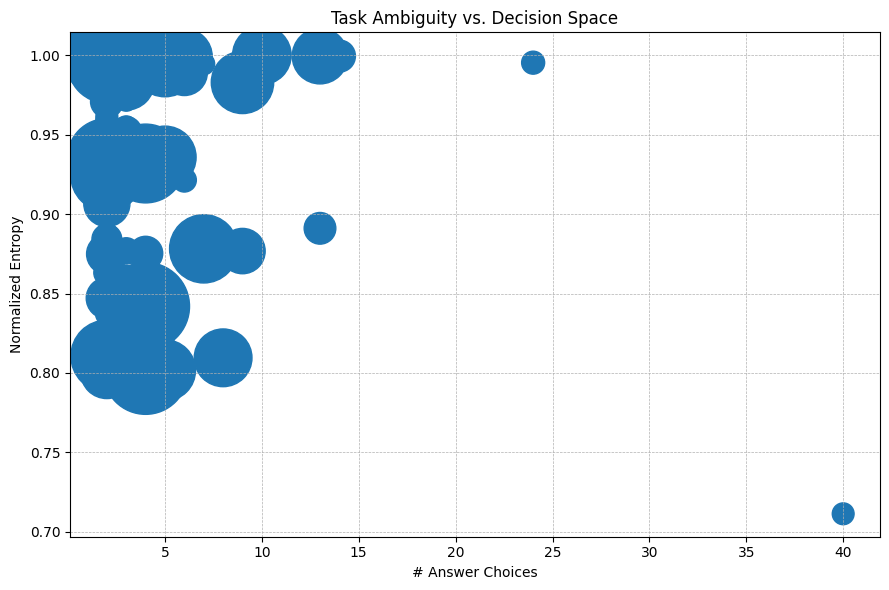

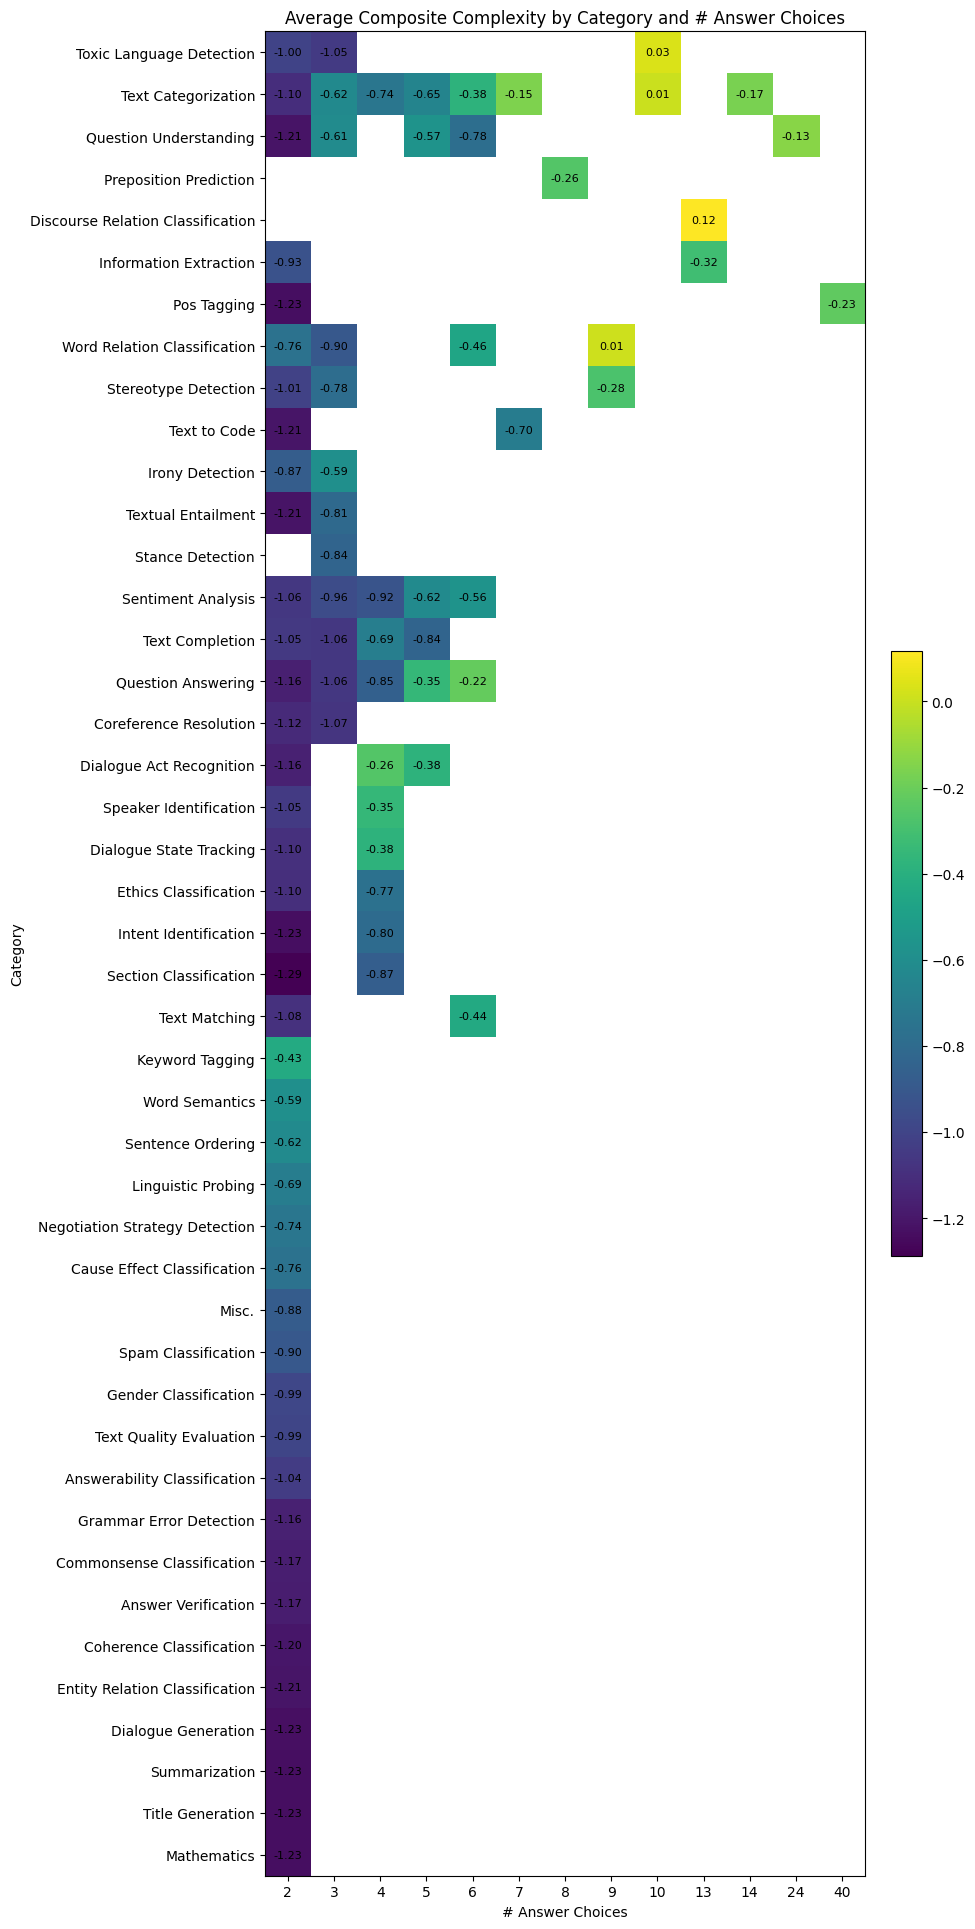

Saved figures:
 - complexity_norm_entropy_hist.png
 - complexity_top_tasks_bar.png
 - complexity_scatter_entropy_vs_choices.png
 - complexity_heatmap_category_choices.png
Also wrote: test_tasks_info_with_complexity.csv


In [ ]:
import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Load data
# -----------------------------
csv_path = "test_tasks_info.csv"  # adjust path if needed
df = pd.read_csv(csv_path)

# Ensure expected columns exist
required_cols = {"Name", "# Instances", "# Answer Choices", "Labels Distribution", "Category"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")

# -----------------------------
# 2) Parse label distributions & compute entropy
# -----------------------------
def safe_parse_dict(s):
    """Parse a dict-like string safely into a Python dict."""
    if isinstance(s, dict):
        return s
    try:
        return ast.literal_eval(s)
    except Exception:
        return {}

def shannon_entropy(label_dist: dict) -> float:
    """Shannon entropy in bits (log base 2)."""
    if not label_dist:
        return 0.0
    probs = np.array([float(p) for p in label_dist.values() if p is not None], dtype=float)
    # Normalize if slightly off (e.g., due to rounding)
    total = probs.sum()
    if total <= 0:
        return 0.0
    probs = probs / total
    # Avoid log(0)
    probs = probs[probs > 0]
    return float(-(probs * np.log2(probs)).sum())

def normalized_entropy(H: float, num_choices: int) -> float:
    """Normalize entropy by the maximum possible entropy log2(K)."""
    if num_choices and num_choices > 1:
        return H / math.log2(num_choices)
    return 0.0

df["_label_dist_dict"] = df["Labels Distribution"].apply(safe_parse_dict)
df["Entropy"] = df["_label_dist_dict"].apply(shannon_entropy)
df["NormEntropy"] = [
    normalized_entropy(H, k) for H, k in zip(df["Entropy"], df["# Answer Choices"])
]

# -----------------------------
# 3) Composite Complexity Score
# -----------------------------
# Complexity increases with entropy & #choices; decreases with #instances.
# You can tune these weights depending on your use case.
alpha = 1.0   # weight for normalized entropy
beta  = 0.3   # weight for log2(#choices)
gamma = 0.2   # weight for log2(#instances) (subtracted)

# Guard against zeros
safe_choices = df["# Answer Choices"].clip(lower=2)  # at least binary
safe_instances = df["# Instances"].clip(lower=1)

df["Complexity"] = (
    alpha * df["NormEntropy"]
    + beta * np.log2(safe_choices)
    - gamma * np.log2(safe_instances)
)

# -----------------------------
# 4) Visualizations (matplotlib only; one chart per figure)
# -----------------------------

# (A) Histogram of Normalized Entropy (intrinsic ambiguity proxy)
plt.figure(figsize=(10, 5))
plt.hist(df["NormEntropy"].dropna(), bins=20)
plt.title("Distribution of Normalized Label Entropy (Task Ambiguity)")
plt.xlabel("Normalized Entropy (0–1)")
plt.ylabel("Count of Tasks")
plt.tight_layout()
plt.savefig("complexity_norm_entropy_hist.png", dpi=200)
plt.show()

# (B) Top-N Tasks by Composite Complexity (bar chart)
TOP_N = 25
top_tasks = df.sort_values("Complexity", ascending=False).head(TOP_N)
plt.figure(figsize=(12, 7))
plt.barh(top_tasks["Name"], top_tasks["Complexity"])
plt.gca().invert_yaxis()
plt.title(f"Top {TOP_N} Tasks by Composite Complexity")
plt.xlabel("Composite Complexity")
plt.ylabel("Task")
plt.tight_layout()
plt.savefig("complexity_top_tasks_bar.png", dpi=200)
plt.show()

# (C) Scatter: NormEntropy vs. #AnswerChoices (marker size = #Instances)
# We use marker size inversely scaled so small datasets (harder to learn) pop a bit.
inv_instances = 1.0 / safe_instances
size = 4000 * (inv_instances / inv_instances.max())  # scale for visibility
plt.figure(figsize=(9, 6))
plt.scatter(df["# Answer Choices"], df["NormEntropy"], s=size)
plt.title("Task Ambiguity vs. Decision Space")
plt.xlabel("# Answer Choices")
plt.ylabel("Normalized Entropy")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.savefig("complexity_scatter_entropy_vs_choices.png", dpi=200)
plt.show()

# (D) Heatmap-like image: Average Complexity by Category × #Choices
# Build a pivot of mean complexity
pivot = (
    df.pivot_table(
        index="Category",
        columns="# Answer Choices",
        values="Complexity",
        aggfunc="mean"
    )
    .sort_values(by=list(df["# Answer Choices"].unique())[::-1], ascending=False)
)

# Matplotlib "imshow" heatmap (no seaborn)
plt.figure(figsize=(max(8, 0.45 * len(pivot.columns) + 4), max(8, 0.35 * len(pivot.index) + 4)))
im = plt.imshow(pivot.values, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Average Composite Complexity by Category and # Answer Choices")
plt.xlabel("# Answer Choices")
plt.ylabel("Category")
plt.xticks(ticks=range(len(pivot.columns)), labels=pivot.columns, rotation=0)
plt.yticks(ticks=range(len(pivot.index)), labels=pivot.index)
# Annotate cells
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("complexity_heatmap_category_choices.png", dpi=200)
plt.show()

# -----------------------------
# 5) Save enriched CSV
# -----------------------------
df_out = df.drop(columns=["_label_dist_dict"])
df_out.to_csv("test_tasks_info_with_complexity.csv", index=False)

print("Saved figures:")
print(" - complexity_norm_entropy_hist.png")
print(" - complexity_top_tasks_bar.png")
print(" - complexity_scatter_entropy_vs_choices.png")
print(" - complexity_heatmap_category_choices.png")
print("Also wrote: test_tasks_info_with_complexity.csv")


### Bias and complexity

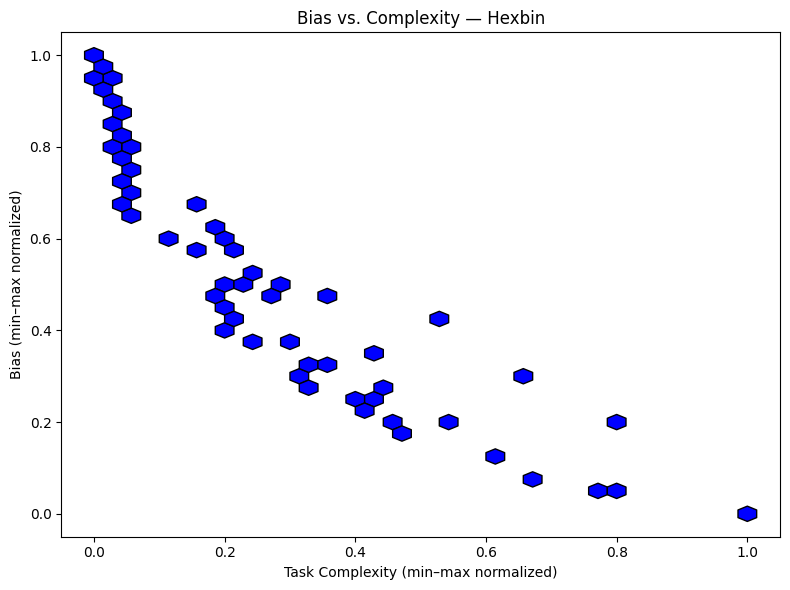

/tmp/ipykernel_3505542/2213584219.py:98: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = dfv.groupby(cats)["bias_norm"]


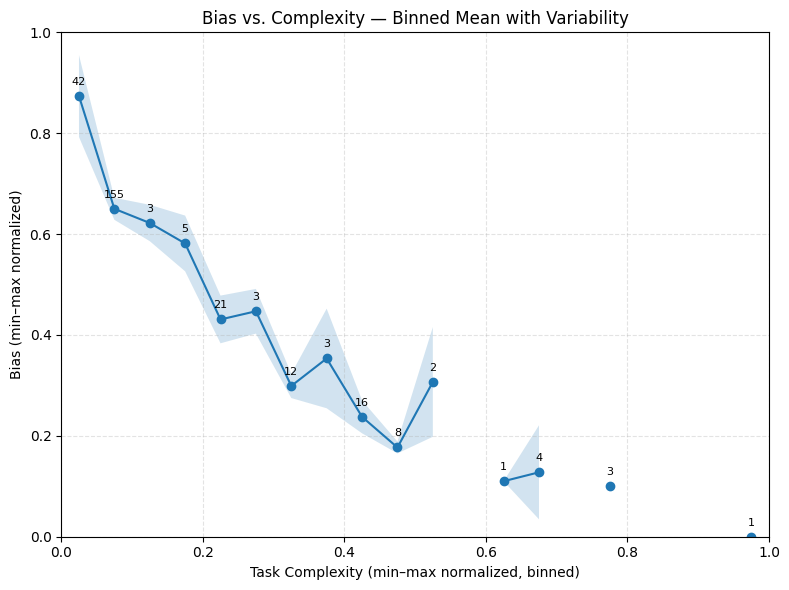

/tmp/ipykernel_3505542/2213584219.py:132: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showfliers=False)


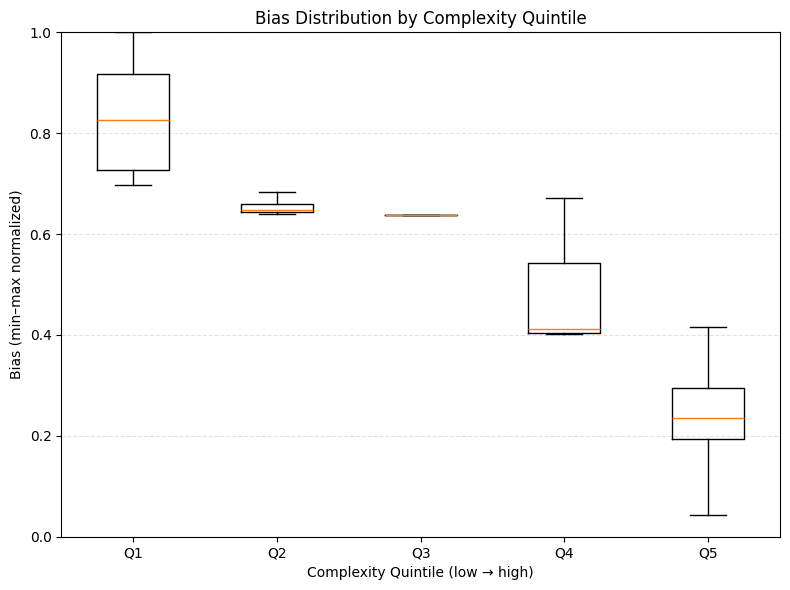

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from pathlib import Path
import matplotlib as mpl

# ========= Load =========
CSV_PATH = "test_tasks_info.csv"  # change if needed
df = pd.read_csv(CSV_PATH)

# ========= Helpers =========
def parse_dist(x):
    """Parse dict-like strings in 'Labels Distribution' into real dicts."""
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return None
    return None

def shannon_entropy(dist_dict):
    """Natural-log entropy: higher → more complex."""
    ps = np.array(list(dist_dict.values()), dtype=float)
    ps = ps[(ps > 0) & (~np.isnan(ps))]
    if len(ps) == 0:
        return 0.0
    return -np.sum(ps * np.log(ps))

def dominant_prob(dist_dict):
    """Max class probability: higher → more biased toward one class."""
    ps = np.array(list(dist_dict.values()), dtype=float)
    ps = ps[(ps >= 0) & (~np.isnan(ps))]
    if len(ps) == 0:
        return np.nan
    return float(np.max(ps))

def min_max_norm(series, new_min=0.0, new_max=1.0):
    """
    Min–max normalization (as in the slide):
      v' = (v - min_A)/(max_A - min_A) * (new_max - new_min) + new_min
    If constant/invalid, returns all new_min.
    """
    s = pd.to_numeric(series, errors="coerce")
    smin, smax = s.min(), s.max()
    if np.isclose(smax, smin) or pd.isna(smin) or pd.isna(smax):
        return pd.Series([new_min] * len(s), index=s.index)
    return ((s - smin) / (smax - smin)) * (new_max - new_min) + new_min

# ========= Compute metrics =========
label_dist = df["Labels Distribution"].apply(parse_dist)
mask_valid = label_dist.apply(lambda d: isinstance(d, dict) and len(d) > 0)

dfv = df[mask_valid].copy()
label_dist = label_dist[mask_valid]

dfv["raw_entropy"] = label_dist.apply(shannon_entropy)
dfv["raw_bias"] = label_dist.apply(dominant_prob)

dfv["complexity_norm"] = min_max_norm(dfv["raw_entropy"], 0.0, 1.0)
dfv["bias_norm"] = min_max_norm(dfv["raw_bias"], 0.0, 1.0)

# Ensure maxima are exactly 1 (up to float tolerance)
assert np.isclose(dfv["complexity_norm"].max(), 1.0, atol=1e-12)
assert np.isclose(dfv["bias_norm"].max(), 1.0, atol=1e-12)

# Save normalized table (optional)
out_csv = Path("normalized_tasks_alt.csv")
dfv[["Name", "# Instances", "# Answer Choices", "Category",
     "raw_entropy", "raw_bias", "complexity_norm", "bias_norm"]].to_csv(out_csv, index=False)

# ========= 1) Density (hexbin, single color) =========
plt.figure(figsize=(8, 6))
hb = plt.hexbin(
    dfv["complexity_norm"], dfv["bias_norm"],
    gridsize=35, extent=(0, 1, 0, 1), mincnt=1
)

# --- Force a flat color on all hexagons ---
hb.set_array(np.ones_like(hb.get_array()))                         # same value in every bin
hb.set_cmap(mpl.colors.ListedColormap(['blue']))               # single color (black)
hb.set_clim(1, 1)                                                 # collapse range so all map to same color
hb.set_edgecolor('#000000')                                       # optional: matching outlines
# (don’t call plt.colorbar)

plt.xlabel("Task Complexity (min–max normalized)")
plt.ylabel("Bias (min–max normalized)")
plt.title("Bias vs. Complexity — Hexbin")
plt.tight_layout()
plt.savefig("hexbin_singlecolor.png", dpi=200, bbox_inches="tight")
plt.show()

# ========= 2) Binned trend (means with ±1 std band) =========
bins = np.linspace(0, 1, 21)  # 20 equal-width bins across [0,1]
cats = pd.cut(dfv["complexity_norm"], bins=bins, include_lowest=True)
grouped = dfv.groupby(cats)["bias_norm"]

bin_centers = (bins[:-1] + bins[1:]) / 2
means = grouped.mean().reindex(cats.cat.categories).values
stds = grouped.std(ddof=0).reindex(cats.cat.categories).values
counts = grouped.size().reindex(cats.cat.categories).values

plt.figure(figsize=(8, 6))
plt.plot(bin_centers, means, marker="o")
upper = np.minimum(1.0, means + stds)
lower = np.maximum(0.0, means - stds)
plt.fill_between(bin_centers, lower, upper, alpha=0.2)
plt.xlabel("Task Complexity (min–max normalized, binned)")
plt.ylabel("Bias (min–max normalized)")
plt.title("Bias vs. Complexity — Binned Mean with Variability")
# annotate with bin counts where data exists
for i, x in enumerate(bin_centers):
    if counts[i] and not np.isnan(means[i]):
        plt.annotate(str(int(counts[i])), (x, means[i]),
                     xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=8)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig("alt_binned_trend.png", dpi=200, bbox_inches="tight")
plt.show()

# ========= 3) Boxplots by complexity quintile =========
dfv["complexity_quintile"] = pd.qcut(dfv["complexity_norm"], 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
order = ["Q1", "Q2", "Q3", "Q4", "Q5"]
data = [dfv.loc[dfv["complexity_quintile"] == q, "bias_norm"].values for q in order]

plt.figure(figsize=(8, 6))
plt.boxplot(data, labels=order, showfliers=False)
plt.xlabel("Complexity Quintile (low → high)")
plt.ylabel("Bias (min–max normalized)")
plt.title("Bias Distribution by Complexity Quintile")
plt.ylim(0, 1)
plt.grid(True, axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig("alt_quintile_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()


## Top 20 tasks and the bottom 20 tasks

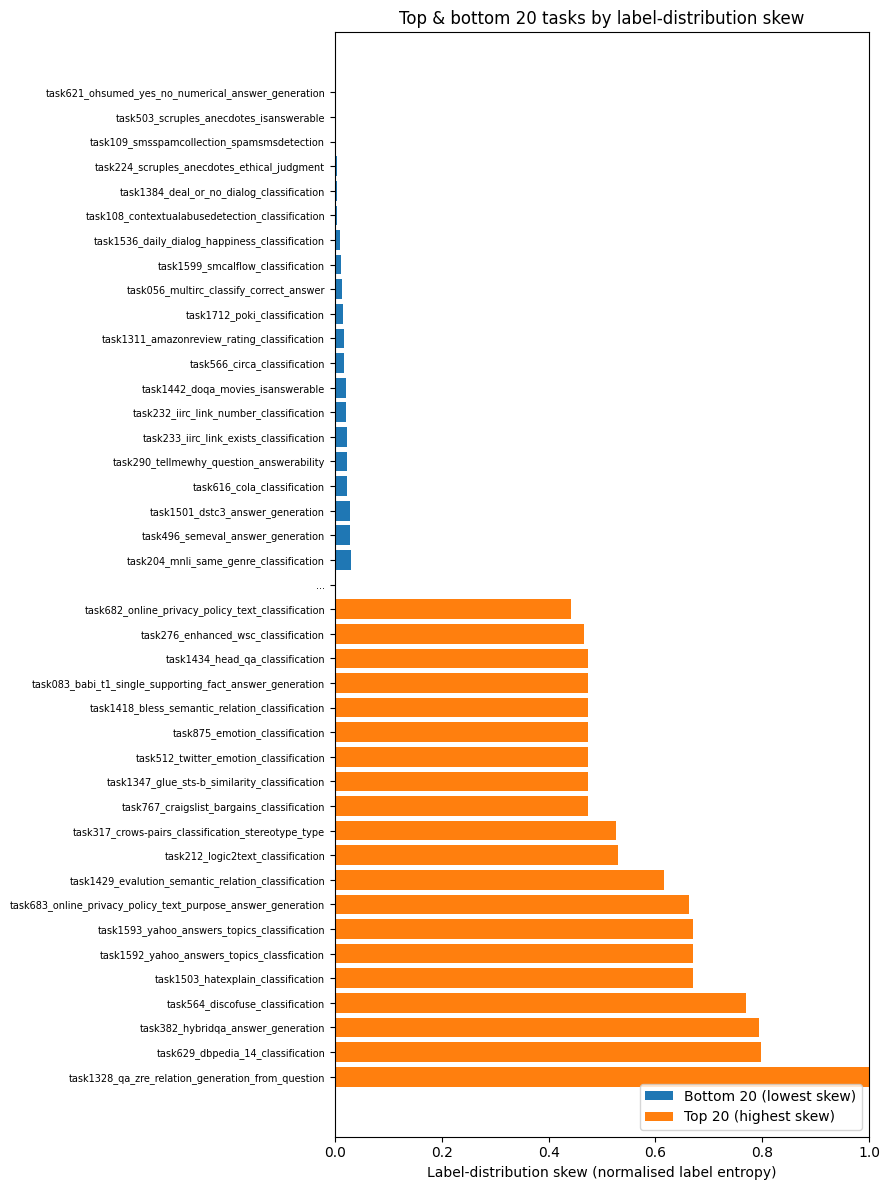

Saved figure (vector): top_bottom20_skew_singlepanel_gap.pdf
Saved figure (raster): top_bottom20_skew_singlepanel_gap.png
Saved tables: clean_top_bottom_tables.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from pathlib import Path

# ========= Config =========
CSV_PATH = "test_tasks_info.csv"
OUT_PDF  = "top_bottom20_skew_singlepanel_gap.pdf"   # vector output (crisp at any scale)
OUT_PNG  = "top_bottom20_skew_singlepanel_gap.png"   # raster fallback, high DPI
OUT_CSV  = "clean_top_bottom_tables.csv"

# ========= Load =========
df = pd.read_csv(CSV_PATH)

# ========= Helpers =========
def parse_dist(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return None
    return None

def shannon_entropy(dist_dict):
    ps = np.array(list(dist_dict.values()), dtype=float)
    ps = ps[(ps > 0) & (~np.isnan(ps))]
    if len(ps) == 0:
        return 0.0
    return -np.sum(ps * np.log(ps))

def dominant_prob(dist_dict):
    ps = np.array(list(dist_dict.values()), dtype=float)
    ps = ps[(ps >= 0) & (~np.isnan(ps))]
    if len(ps) == 0:
        return np.nan
    return float(np.max(ps))

def min_max_norm(series, new_min=0.0, new_max=1.0):
    # v' = (v - min_A)/(max_A - min_A) * (new_max - new_min) + new_min
    s = pd.to_numeric(series, errors="coerce")
    smin, smax = s.min(), s.max()
    if np.isclose(smax, smin) or pd.isna(smin) or pd.isna(smax):
        return pd.Series([new_min] * len(s), index=s.index)
    return ((s - smin) / (smax - smin)) * (new_max - new_min) + new_min

# ========= Compute metrics =========
label_dist = df["Labels Distribution"].apply(parse_dist)
mask_valid = label_dist.apply(lambda d: isinstance(d, dict) and len(d) > 0)
dfv = df[mask_valid].copy()
label_dist = label_dist[mask_valid]

# Label-distribution skew is measured as the Shannon entropy of the
# empirical label distribution; the dominant-class probability is the
# accompanying label-bias measure. Both are min-max normalised to [0, 1].
dfv["raw_skew_entropy"] = label_dist.apply(shannon_entropy)   # skew (entropy)
dfv["raw_bias"]         = label_dist.apply(dominant_prob)     # bias proxy

dfv["skew_norm"] = min_max_norm(dfv["raw_skew_entropy"], 0.0, 1.0)
dfv["bias_norm"] = min_max_norm(dfv["raw_bias"],         0.0, 1.0)

# Ensure maxima are 1
assert np.isclose(dfv["skew_norm"].max(), 1.0, atol=1e-12)
assert np.isclose(dfv["bias_norm"].max(), 1.0, atol=1e-12)

# ========= Pick bottom 20 & top 20 by normalized skew =========
df_sorted = dfv.sort_values("skew_norm", ascending=True)

bottom20 = df_sorted.head(20).copy()
# Show bottom-20 in ascending order (lowest -> higher within the bottom set)
bottom20 = bottom20.sort_values("skew_norm", ascending=True)

top20 = df_sorted.tail(20).copy()
# Show ascending within this group (low -> high).
top20 = top20.sort_values("skew_norm", ascending=True)

# Save details (optional)
tables = pd.concat([
    bottom20.assign(Group="Bottom 20")[["Name", "skew_norm", "bias_norm", "Category"]],
    top20.assign(Group="Top 20")[["Name", "skew_norm", "bias_norm", "Category"]],
])
Path(OUT_CSV).parent.mkdir(parents=True, exist_ok=True)
tables.to_csv(OUT_CSV, index=False)

# ========= Build single-panel dataset with a GAP row =========
gap_label = "..."
gap_value = np.nan  # NaN -> no bar drawn; still creates a tick/space

labels = list(bottom20["Name"]) + [gap_label] + list(top20["Name"])
values = list(bottom20["skew_norm"].astype(float)) + [gap_value] + list(top20["skew_norm"].astype(float))

y = np.arange(len(labels))

# Indices for coloring groups
idx_bottom = np.arange(0, len(bottom20))
idx_gap    = np.array([len(bottom20)])
idx_top    = np.arange(len(bottom20) + 1, len(labels))

values_arr = np.array(values, dtype=float)

# ========= Plot (single panel) =========
plt.figure(figsize=(9, 12))

# Plot bottom 20 (low skew)
plt.barh(y[idx_bottom], values_arr[idx_bottom],
         label="Bottom 20 (lowest skew)", linewidth=0)

# Plot top 20 (high skew)
plt.barh(y[idx_top], values_arr[idx_top],
         label="Top 20 (highest skew)", linewidth=0)

# Axis/labels
plt.yticks(y, labels, fontsize=7)
plt.gca().invert_yaxis()  # first label (bottom 20) at the top
plt.xlim(0, 1)
plt.xlabel("Label-distribution skew (normalised label entropy)")
plt.title("Top & bottom 20 tasks by label-distribution skew")
plt.legend(loc="lower right")
plt.tight_layout()

# Vector PDF for crisp rendering at any scale; PNG fallback at high DPI.
plt.savefig(OUT_PDF, bbox_inches="tight")
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure (vector):", OUT_PDF)
print("Saved figure (raster):", OUT_PNG)
print("Saved tables:", OUT_CSV)